# Deliverable 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

## Data Preprocessing

In [2]:
df = pd.read_csv('CIS2022_PUMF_CLEANED.csv')
target = 'After-tax income'
df = df.dropna(subset=[target])

selected_features = [
    'Major source of income',
    "Person's age group as of December 31 of refyear",
    'Flag - Person was employed during the reference year',
    'Highest level of education of person, 2nd grouping',
    'Annual labour force status',
    'Age group of youngest person in economic family',
    'Economic family type',
    'Marital status',
    'Age group of oldest person in economic family',
    'Flag - Person completed high school',
    'Census family composition'
]

X = df[selected_features].copy()
y = df[target].copy()

for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 64930, Test: 16233


In [3]:
def evaluate(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'R2': round(r2, 4), 'Adj_R2': round(adj_r2, 4),
            'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE': round(mape, 2)}

## Baseline Models (Deliverable 1)

In [4]:
baseline_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
}

baseline_results = {}
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    baseline_results[name] = evaluate(y_test, y_pred, X_train.shape[1])

baseline_df = pd.DataFrame(baseline_results).T
baseline_df.index.name = 'Model'
print(baseline_df.to_string())

                       R2  Adj_R2      RMSE       MAE    MAPE
Model                                                        
Linear Regression  0.2358  0.2353  37166.01  21227.64  277.14
Decision Tree      0.1418  0.1412  39387.53  20496.00  266.37
Random Forest      0.2628  0.2623  36504.98  19098.95  220.37


## Task 1: Outlier & Imbalance Analysis

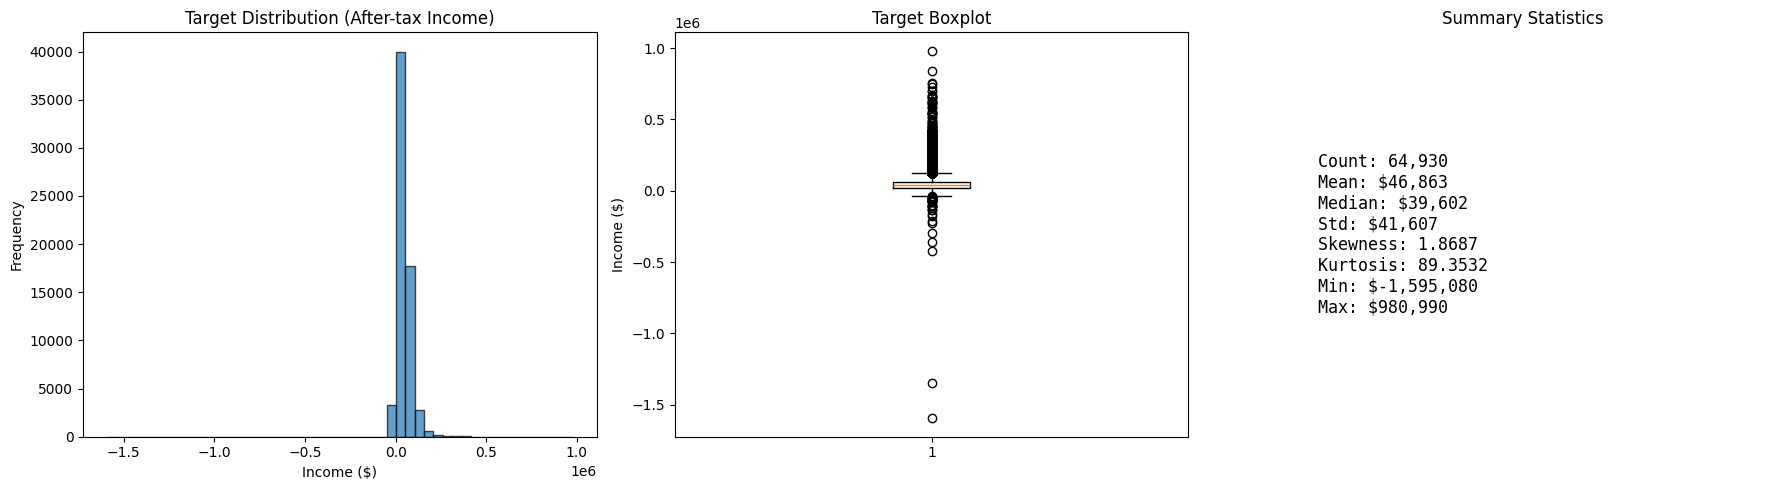

In [5]:
# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(y_train, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Target Distribution (After-tax Income)')
axes[0].set_xlabel('Income ($)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(y_train, vert=True)
axes[1].set_title('Target Boxplot')
axes[1].set_ylabel('Income ($)')

stats_text = (f"Count: {len(y_train):,}\n"
              f"Mean: ${y_train.mean():,.0f}\n"
              f"Median: ${y_train.median():,.0f}\n"
              f"Std: ${y_train.std():,.0f}\n"
              f"Skewness: {y_train.skew():.4f}\n"
              f"Kurtosis: {y_train.kurtosis():.4f}\n"
              f"Min: ${y_train.min():,.0f}\n"
              f"Max: ${y_train.max():,.0f}")
axes[2].text(0.1, 0.5, stats_text, fontsize=12, family='monospace',
             transform=axes[2].transAxes, verticalalignment='center')
axes[2].set_title('Summary Statistics')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Target outliers (IQR)
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = y_train[(y_train < lower_bound) | (y_train > upper_bound)]

print(f'Q1: ${Q1:,.0f}')
print(f'Q3: ${Q3:,.0f}')
print(f'IQR: ${IQR:,.0f}')
print(f'Lower Bound: ${lower_bound:,.0f}')
print(f'Upper Bound: ${upper_bound:,.0f}')
print(f'Total Outliers: {len(outliers)} ({len(outliers)/len(y_train)*100:.1f}%)')
print(f'  Below Lower: {(y_train < lower_bound).sum()}')
print(f'  Above Upper: {(y_train > upper_bound).sum()}')
print(f'Negative Values: {(y_train < 0).sum()}')
print(f'Zero Values: {(y_train == 0).sum()}')

Q1: $21,875
Q3: $62,570
IQR: $40,695
Lower Bound: $-39,168
Upper Bound: $123,612
Total Outliers: 2348 (3.6%)
  Below Lower: 32
  Above Upper: 2316
Negative Values: 265
Zero Values: 1459


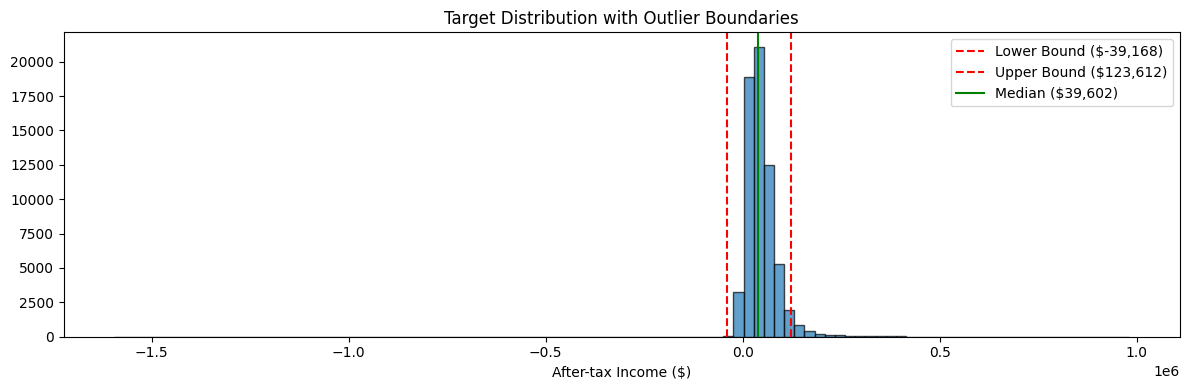

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(y_train, bins=100, edgecolor='black', alpha=0.7)
ax.axvline(lower_bound, color='red', linestyle='--', label=f'Lower Bound (${lower_bound:,.0f})')
ax.axvline(upper_bound, color='red', linestyle='--', label=f'Upper Bound (${upper_bound:,.0f})')
ax.axvline(y_train.median(), color='green', linestyle='-', label=f'Median (${y_train.median():,.0f})')
ax.set_title('Target Distribution with Outlier Boundaries')
ax.set_xlabel('After-tax Income ($)')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Feature outliers
print('Feature Outliers (IQR Method):')
print(f'{"Feature":<55} {"Q1":>6} {"Q3":>6} {"IQR":>6} {"Outliers":>10}')
for col in X_train.columns:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    if iqr > 0:
        out_count = ((X_train[col] < q1 - 1.5*iqr) | (X_train[col] > q3 + 1.5*iqr)).sum()
        print(f'{col:<55} {q1:>6.0f} {q3:>6.0f} {iqr:>6.0f} {out_count:>6} ({out_count/len(X_train)*100:.1f}%)')
    else:
        print(f'{col:<55} {q1:>6.0f} {q3:>6.0f} {"0":>6} {"N/A":>10}')

Feature Outliers (IQR Method):
Feature                                                     Q1     Q3    IQR   Outliers
Major source of income                                       2      4      2      0 (0.0%)
Person's age group as of December 31 of refyear              8     14      6      0 (0.0%)
Flag - Person was employed during the reference year         1      2      1      0 (0.0%)
Highest level of education of person, 2nd grouping           2      4      2      0 (0.0%)
Annual labour force status                                   1      3      2   2146 (3.3%)
Age group of youngest person in economic family              4     13      9      0 (0.0%)
Economic family type                                        21     24      3  22331 (34.4%)
Marital status                                               1      3      2      0 (0.0%)
Age group of oldest person in economic family                9     15      6      0 (0.0%)
Flag - Person completed high school                          

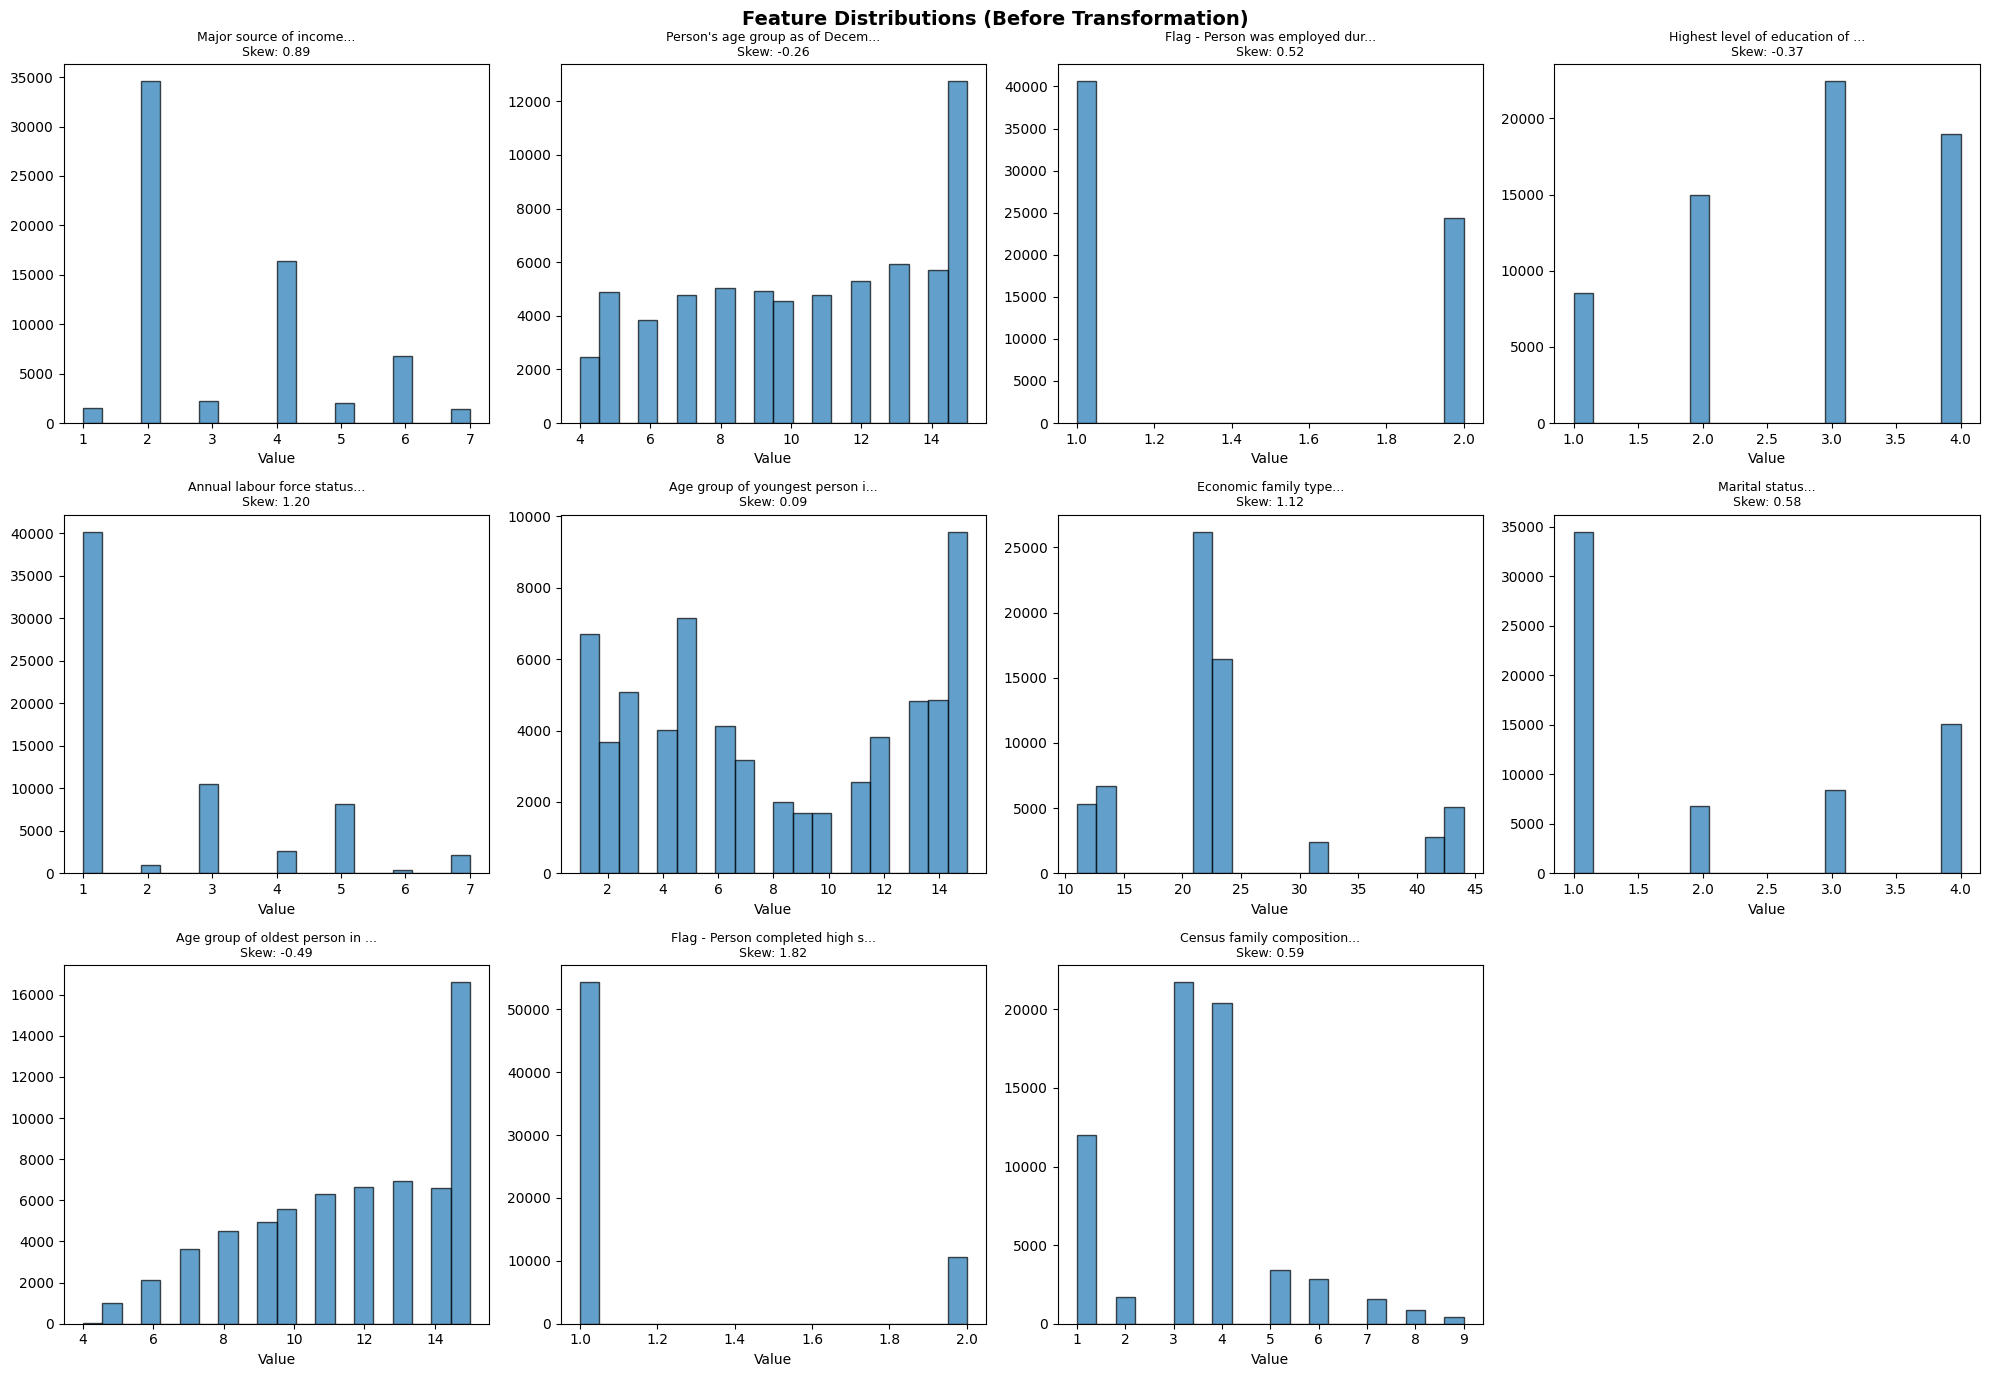

In [9]:
# Feature distributions
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
for i, col in enumerate(X_train.columns):
    ax = axes[i // 4][i % 4]
    ax.hist(X_train[col], bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col[:30]}...\nSkew: {X_train[col].skew():.2f}', fontsize=9)
    ax.set_xlabel('Value')
for j in range(len(X_train.columns), 12):
    axes[j // 4][j % 4].axis('off')
plt.suptitle('Feature Distributions (Before Transformation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 1: Apply Transformations (on Features)

In [10]:
# 1. Standardization (zero mean, unit variance)
std_scaler = StandardScaler()
X_train_std = pd.DataFrame(std_scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_std = pd.DataFrame(std_scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# 2. Normalization (MinMax to [0, 1])
mm_scaler = MinMaxScaler()
X_train_mm = pd.DataFrame(mm_scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_mm = pd.DataFrame(mm_scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# 3. Robust Scaling (median/IQR based)
rob_scaler = RobustScaler()
X_train_rob = pd.DataFrame(rob_scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_rob = pd.DataFrame(rob_scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# 4. Log Transform (log1p since all feature values >= 0)
X_train_log = np.log1p(X_train)
X_test_log = np.log1p(X_test)

print('All 4 transformations applied to features.')

All 4 transformations applied to features.


In [11]:
# Skewness: before vs after
skew_data = []
for col in X_train.columns:
    skew_data.append({
        'Feature': col[:40],
        'Original': round(X_train[col].skew(), 4),
        'Standardized': round(X_train_std[col].skew(), 4),
        'Normalized': round(X_train_mm[col].skew(), 4),
        'Robust': round(X_train_rob[col].skew(), 4),
        'Log': round(X_train_log[col].skew(), 4)
    })
skew_df = pd.DataFrame(skew_data)
print(skew_df.to_string(index=False))

                                 Feature  Original  Standardized  Normalized  Robust     Log
                  Major source of income    0.8939        0.8939      0.8939  0.8939  0.4930
Person's age group as of December 31 of    -0.2605       -0.2605     -0.2605 -0.2605 -0.6642
Flag - Person was employed during the re    0.5175        0.5175      0.5175  0.5175  0.5175
Highest level of education of person, 2n   -0.3673       -0.3673     -0.3673 -0.3673 -0.7916
              Annual labour force status    1.1973        1.1973      1.1973  1.1973  0.8202
Age group of youngest person in economic    0.0880        0.0880      0.0880  0.0880 -0.5708
                    Economic family type    1.1243        1.1243      1.1243  1.1243  0.1270
                          Marital status    0.5767        0.5767      0.5767  0.5767  0.4326
Age group of oldest person in economic f   -0.4937       -0.4937     -0.4937 -0.4937 -0.8765
     Flag - Person completed high school    1.8241        1.8241      

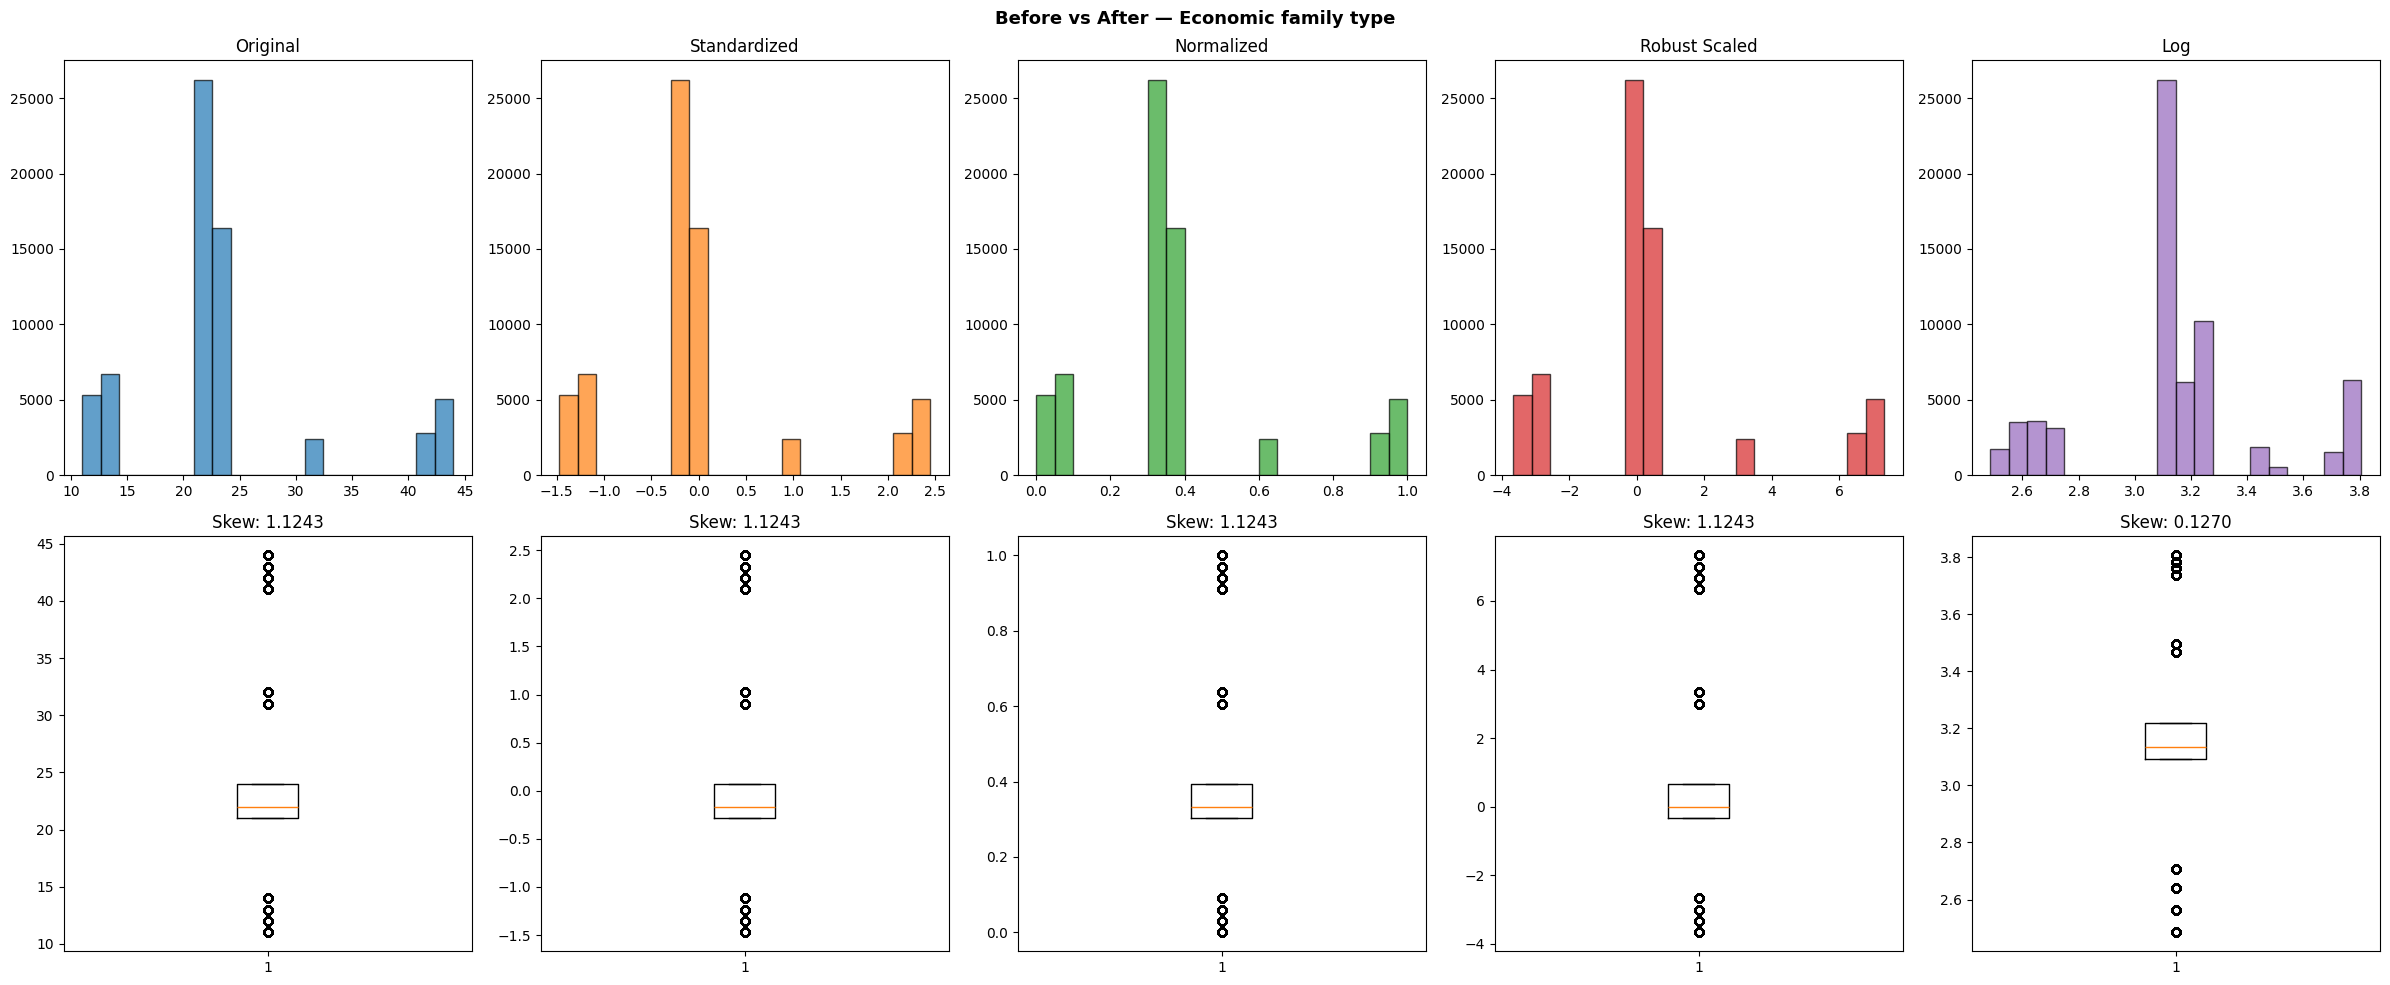

In [12]:
# Before vs After: Economic family type (most skewed)
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
sample_feat = 'Economic family type'
transforms_plot = {
    'Original': X_train[sample_feat],
    'Standardized': X_train_std[sample_feat],
    'Normalized': X_train_mm[sample_feat],
    'Robust Scaled': X_train_rob[sample_feat],
    'Log': X_train_log[sample_feat]
}
for i, (name, data) in enumerate(transforms_plot.items()):
    axes[0, i].hist(data, bins=20, edgecolor='black', alpha=0.7, color=f'C{i}')
    axes[0, i].set_title(f'{name}')
    axes[1, i].boxplot(data)
    axes[1, i].set_title(f'Skew: {skew(data):.4f}')
plt.suptitle(f'Before vs After — {sample_feat}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

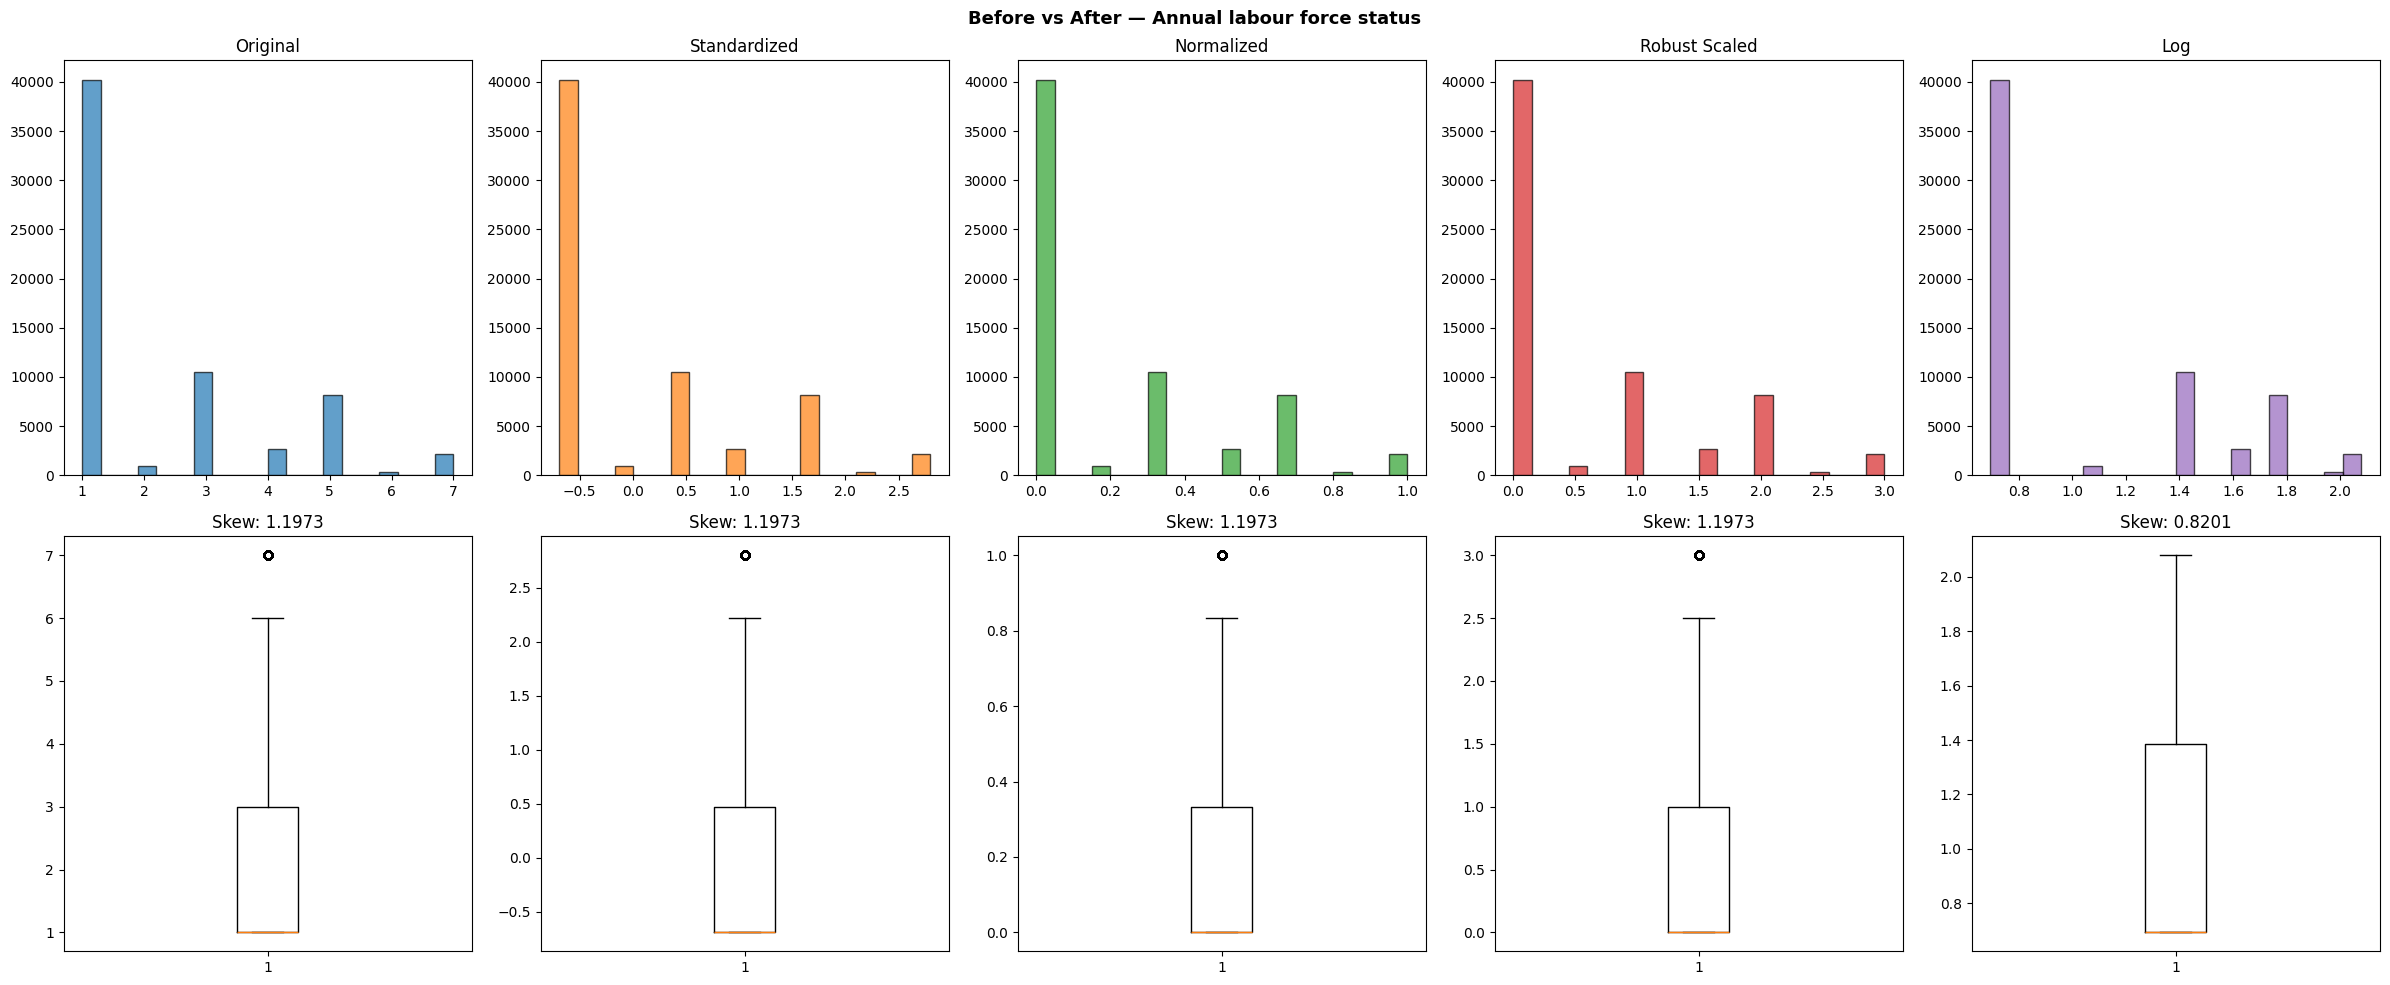

In [13]:
# Before vs After: Annual labour force status (2nd most skewed)
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
sample_feat2 = 'Annual labour force status'
transforms_plot2 = {
    'Original': X_train[sample_feat2],
    'Standardized': X_train_std[sample_feat2],
    'Normalized': X_train_mm[sample_feat2],
    'Robust Scaled': X_train_rob[sample_feat2],
    'Log': X_train_log[sample_feat2]
}
for i, (name, data) in enumerate(transforms_plot2.items()):
    axes[0, i].hist(data, bins=20, edgecolor='black', alpha=0.7, color=f'C{i}')
    axes[0, i].set_title(f'{name}')
    axes[1, i].boxplot(data)
    axes[1, i].set_title(f'Skew: {skew(data):.4f}')
plt.suptitle(f'Before vs After — {sample_feat2}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Compare model performance: Original vs each transformation
models_to_test = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
}

datasets = {
    'Original': (X_train, X_test),
    'Standardization': (X_train_std, X_test_std),
    'Normalization': (X_train_mm, X_test_mm),
    'Robust Scaling': (X_train_rob, X_test_rob),
    'Log Transform': (X_train_log, X_test_log),
}

n_feat = X_train.shape[1]
transform_results = {}

for model_name, model_template in models_to_test.items():
    for ds_name, (Xtr, Xte) in datasets.items():
        model = clone(model_template)
        model.fit(Xtr, y_train)
        pred = model.predict(Xte)
        key = f'{model_name} + {ds_name}'
        transform_results[key] = evaluate(y_test, pred, n_feat)

transform_df = pd.DataFrame(transform_results).T
transform_df.index.name = 'Model + Transformation'
print(transform_df.to_string())

                                         R2  Adj_R2      RMSE       MAE    MAPE
Model + Transformation                                                         
Linear Regression + Original         0.2358  0.2353  37166.01  21227.64  277.14
Linear Regression + Standardization  0.2358  0.2353  37166.01  21227.64  277.14
Linear Regression + Normalization    0.2358  0.2353  37166.01  21227.64  277.14
Linear Regression + Robust Scaling   0.2358  0.2353  37166.01  21227.64  277.14
Linear Regression + Log Transform    0.2346  0.2341  37195.34  21297.16  274.82
Ridge + Original                     0.2358  0.2353  37166.00  21227.59  277.14
Ridge + Standardization              0.2358  0.2353  37166.01  21227.61  277.14
Ridge + Normalization                0.2358  0.2353  37166.05  21227.40  277.14
Ridge + Robust Scaling               0.2358  0.2353  37166.01  21227.55  277.14
Ridge + Log Transform                0.2346  0.2341  37195.27  21296.73  274.82
Random Forest + Original             0.2

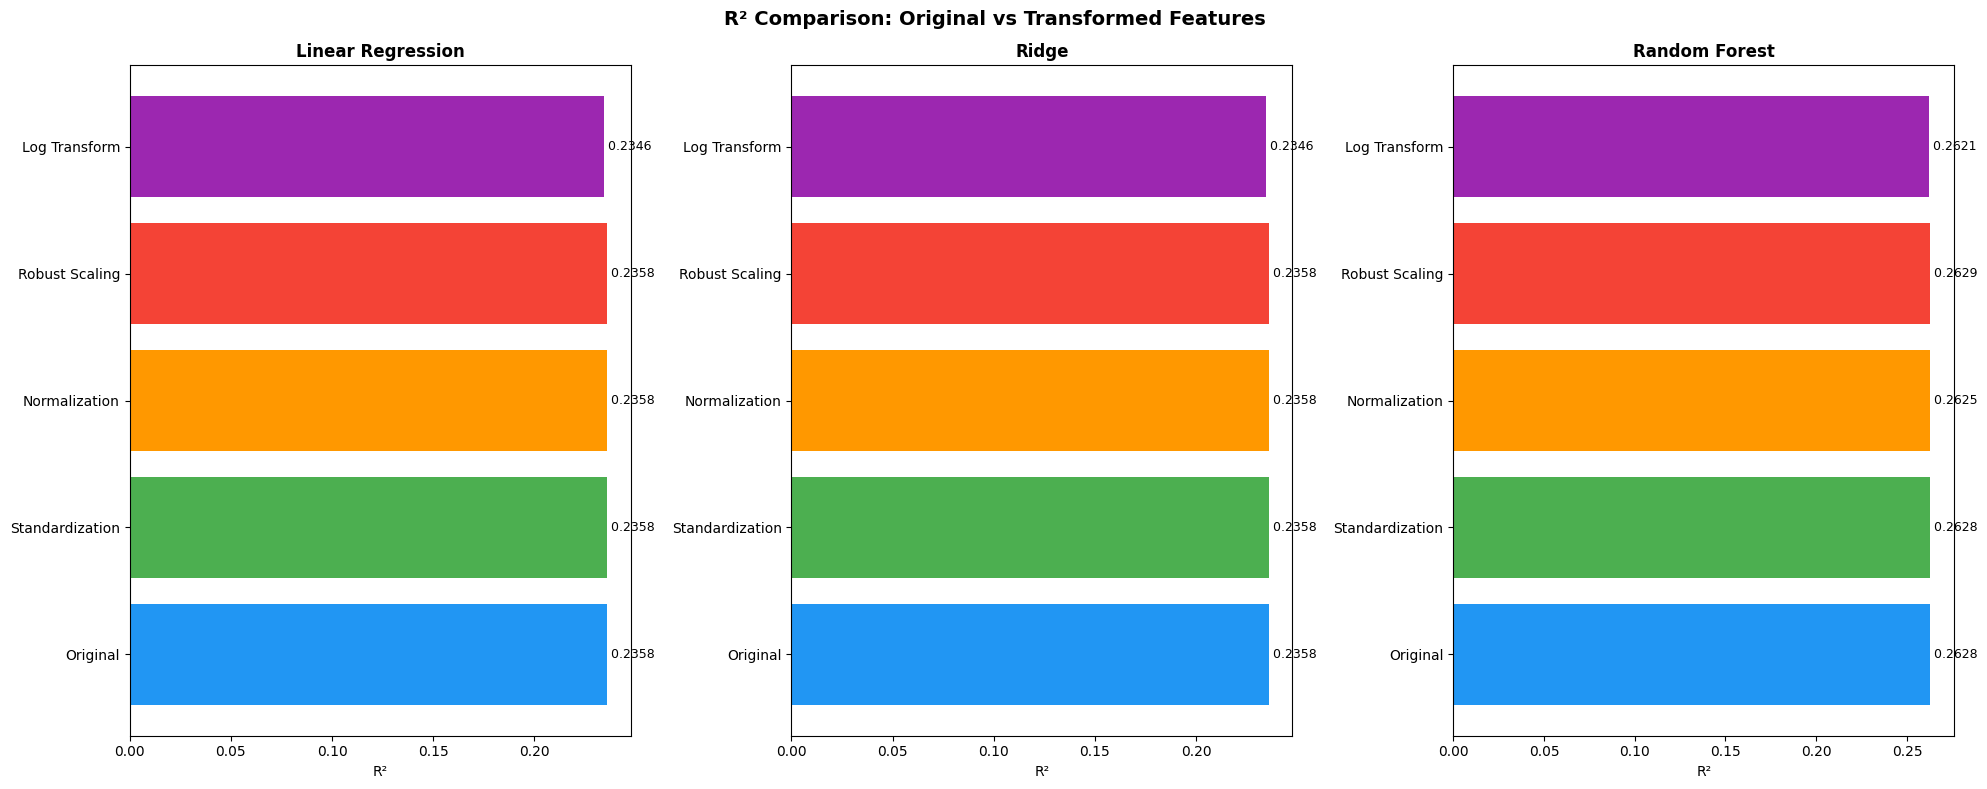

In [15]:
# Visual comparison per model
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
ds_names = list(datasets.keys())
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

for idx, model_name in enumerate(models_to_test.keys()):
    r2_vals = [transform_results[f'{model_name} + {ds}']['R2'] for ds in ds_names]
    axes[idx].barh(ds_names, r2_vals, color=colors)
    axes[idx].set_title(f'{model_name}', fontweight='bold')
    axes[idx].set_xlabel('R²')
    for j, v in enumerate(r2_vals):
        axes[idx].text(v, j, f' {v:.4f}', va='center', fontsize=9)

plt.suptitle('R² Comparison: Original vs Transformed Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 3: Hyperparameter Tuning (GridSearchCV)

In [16]:
# Decision Tree
dt_param_grid = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)
dt_grid.fit(X_train, y_train)

print(f'Decision Tree Best Params: {dt_grid.best_params_}')
print(f'Decision Tree Best CV R2: {dt_grid.best_score_:.4f}')
print(f'Total combinations: {len(dt_grid.cv_results_["params"])}')

Decision Tree Best Params: {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
Decision Tree Best CV R2: 0.3404
Total combinations: 36


In [17]:
# Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)
rf_grid.fit(X_train, y_train)

print(f'Random Forest Best Params: {rf_grid.best_params_}')
print(f'Random Forest Best CV R2: {rf_grid.best_score_:.4f}')
print(f'Total combinations: {len(rf_grid.cv_results_["params"])}')

Random Forest Best Params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Random Forest Best CV R2: 0.3543
Total combinations: 18


In [ ]:
# Gradient Boosting
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)
gb_grid.fit(X_train, y_train)

print(f'Gradient Boosting Best Params: {gb_grid.best_params_}')
print(f'Gradient Boosting Best CV R2: {gb_grid.best_score_:.4f}')
print(f'Total combinations: {len(gb_grid.cv_results_["params"])}')

In [ ]:
grid_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Best CV R2': [round(dt_grid.best_score_, 4), round(rf_grid.best_score_, 4), round(gb_grid.best_score_, 4)],
    'Best Params': [str(dt_grid.best_params_), str(rf_grid.best_params_), str(gb_grid.best_params_)],
    'Total Combos': [len(dt_grid.cv_results_['params']), len(rf_grid.cv_results_['params']), len(gb_grid.cv_results_['params'])]
})
print(grid_summary.to_string(index=False))

## Task 4: Model Evaluation & Best Model Selection

In [ ]:
tuned_results = {}

y_pred_dt = dt_grid.best_estimator_.predict(X_test)
tuned_results['Decision Tree (Tuned)'] = evaluate(y_test, y_pred_dt, n_feat)

y_pred_rf = rf_grid.best_estimator_.predict(X_test)
tuned_results['Random Forest (Tuned)'] = evaluate(y_test, y_pred_rf, n_feat)

y_pred_gb = gb_grid.best_estimator_.predict(X_test)
tuned_results['Gradient Boosting (Tuned)'] = evaluate(y_test, y_pred_gb, n_feat)

tuned_df = pd.DataFrame(tuned_results).T
tuned_df.index.name = 'Model'
print(tuned_df.to_string())

In [ ]:
# Full D1 vs D2 comparison
all_results = {}
for name, res in baseline_results.items():
    all_results[f'{name} (D1 Baseline)'] = res
for name, res in tuned_results.items():
    all_results[f'{name} (D2)'] = res

comparison_df = pd.DataFrame(all_results).T
comparison_df.index.name = 'Model'
print(comparison_df.to_string())

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_plot = ['R2', 'Adj_R2', 'RMSE', 'MAE']
titles = ['R² (higher = better)', 'Adjusted R² (higher = better)',
          'RMSE (lower = better)', 'MAE (lower = better)']

for i, (metric, title) in enumerate(zip(metrics_plot, titles)):
    ax = axes[i // 2][i % 2]
    colors = ['#90CAF9' if 'D1' in idx else '#4CAF50' for idx in comparison_df.index]
    bars = ax.barh(comparison_df.index, comparison_df[metric], color=colors)
    ax.set_title(title, fontweight='bold')
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f' {val}', va='center', fontsize=8)

plt.suptitle('D1 Baseline vs D2 Tuned Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
best_model_name = comparison_df['R2'].idxmax()
print(f'Best Overall Model: {best_model_name}')
print(f'R2: {comparison_df.loc[best_model_name, "R2"]}')
print(f'Adj R2: {comparison_df.loc[best_model_name, "Adj_R2"]}')
print(f'RMSE: {comparison_df.loc[best_model_name, "RMSE"]}')
print(f'MAE: {comparison_df.loc[best_model_name, "MAE"]}')
print(f'MAPE: {comparison_df.loc[best_model_name, "MAPE"]}')

In [ ]:
# D1 vs D2 improvement
print('D1 vs D2 Improvement:\n')
for model_base in ['Decision Tree', 'Random Forest']:
    d1 = baseline_results[model_base]
    d2 = tuned_results[f'{model_base} (Tuned)']
    print(f'--- {model_base} ---')
    for metric in ['R2', 'Adj_R2', 'RMSE', 'MAE']:
        change = d2[metric] - d1[metric]
        pct = (change / abs(d1[metric])) * 100 if d1[metric] != 0 else 0
        print(f'  {metric}: {d1[metric]} -> {d2[metric]} ({"+" if change > 0 else ""}{change:.2f}, {pct:+.1f}%)')
    print()